# OFI as a short-horizon price predictor — exploration

Sanity checks and final figures. All logic lives in `src/`; this notebook only calls it.
Runs top-to-bottom in ~2 minutes. See `README.md` for the full writeup.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.loader import load_lobster, sanity_report
from src.features import build_features, ofi_per_event
from src.target import future_return
from src.model import fit_eval, run_grid
from src.backtest import threshold_sweep

DATA = pathlib.Path.cwd().parent / 'data'
book = load_lobster(DATA / 'AAPL_2012-06-21_34200000_57600000_message_5.csv',
                    DATA / 'AAPL_2012-06-21_34200000_57600000_orderbook_5.csv')
sanity_report(book)

{'n_events': 263533,
 'session_minutes': np.float64(359.9965986844333),
 'events_per_second': np.float64(12.20071712543264),
 'mid_first': np.float64(586.73),
 'mid_last': np.float64(578.3299999999999),
 'median_spread': np.float64(0.14999999999997726),
 'mean_spread': np.float64(0.15578504399828652),
 'median_l1_depth_shares': 201.0}

## 1. Eye test: mid path, spread, depth
A down day (−$8). Median spread 15¢ on a ~$585 stock — wide in ticks. That 15¢ is the cost hurdle the strategy faces later.

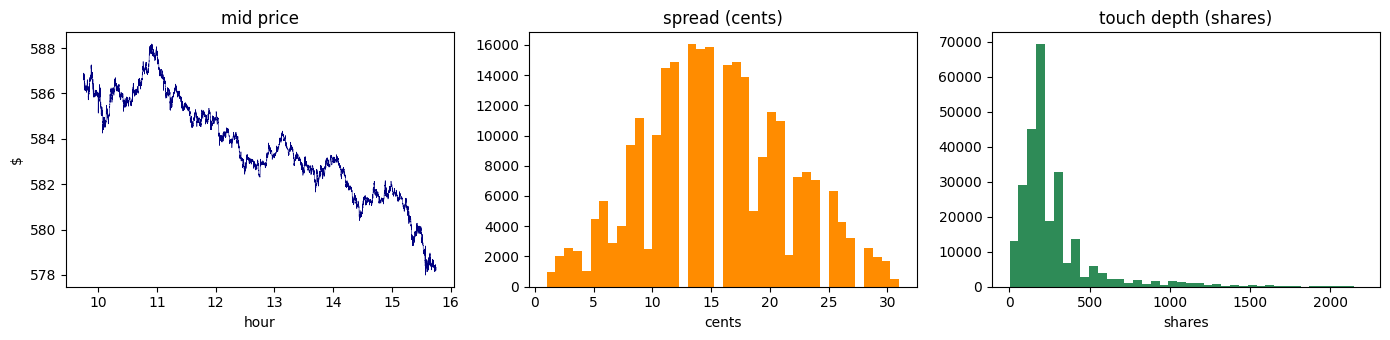

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(book['time'] / 3600, book['mid'], lw=0.4, color='navy')
axes[0].set(title='mid price', xlabel='hour', ylabel='$')
sc = book['spread'] * 100
axes[1].hist(sc[sc < sc.quantile(0.99)], bins=40, color='darkorange')
axes[1].set(title='spread (cents)', xlabel='cents')
depth = book['bid_size_1'] + book['ask_size_1']
axes[2].hist(depth[depth < depth.quantile(0.99)], bins=40, color='seagreen')
axes[2].set(title='touch depth (shares)', xlabel='shares')
plt.tight_layout()

## 2. OFI sanity: per-event distribution
Heavy-tailed and centered near zero, as expected — most events nudge a queue by a few hundred shares.

count    263533.0
mean         -0.7
std          90.7
min      -15000.0
25%           0.0
50%           0.0
75%           0.0
max        6606.0
Name: ofi_event_l1, dtype: float64


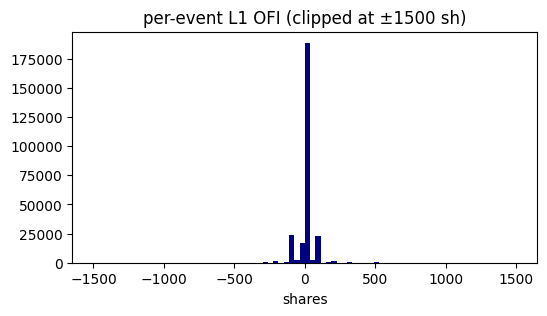

In [3]:
ofi1 = ofi_per_event(book, 1)
print(ofi1.describe().round(1))
clip = ofi1.clip(-1500, 1500)
plt.figure(figsize=(6, 3))
plt.hist(clip, bins=80, color='navy')
plt.title('per-event L1 OFI (clipped at ±1500 sh)')
plt.xlabel('shares');

## 3. Headline regression: 50-event multi-level OFI → next 50 events of mid
Chronological 70/30 split, train-only standardization, HAC t-stats.

In [4]:
H = 50
feats = build_features(book, window=H)
y = future_return(book['mid'], H)
res = fit_eval(feats['ofi_5lvl'], y, horizon=H)
pd.Series(res.as_dict())

feature          ofi_5lvl
target        fret_mid_50
horizon                50
n_train            184403
n_test              79031
beta             0.008084
beta_tstat      10.106233
r2_train         0.016166
r2_oos           0.040841
corr_oos         0.210678
dtype: object

## 4. Full grid + the microprice trap
Note the `qimb → microprice` cells: best R² in the grid, *negative* β, |t| ≈ 70.
Not alpha — queue imbalance is inside the microprice formula, so this regression
rediscovers its own definition (mean reversion of the microprice-vs-mid gap).
Headline results use the mid for exactly this reason.

In [5]:
grid = run_grid(feats, book, ['ofi_l1', 'ofi_5lvl', 'qimb', 'trade_imb'], [H], ['mid', 'microprice'])
grid[['feature', 'target', 'beta', 'beta_tstat', 'r2_oos']].round(4)

,feature,target,beta,beta_tstat,r2_oos
0,ofi_l1,fret_mid_50,0.0098,8.9359,0.0334
1,ofi_5lvl,fret_mid_50,0.0081,10.1062,0.0408
2,qimb,fret_mid_50,0.0019,2.9717,0.0031
3,trade_imb,fret_mid_50,0.0095,12.4792,0.0343
4,ofi_l1,fret_microprice_50,0.0075,6.0244,0.0106
5,ofi_5lvl,fret_microprice_50,0.0106,10.8234,0.0258
6,qimb,fret_microprice_50,-0.0358,-44.7260,0.0796
7,trade_imb,fret_microprice_50,0.0103,11.3672,0.0200


## 5. Final figures (saved by `python -m src.run_all`)

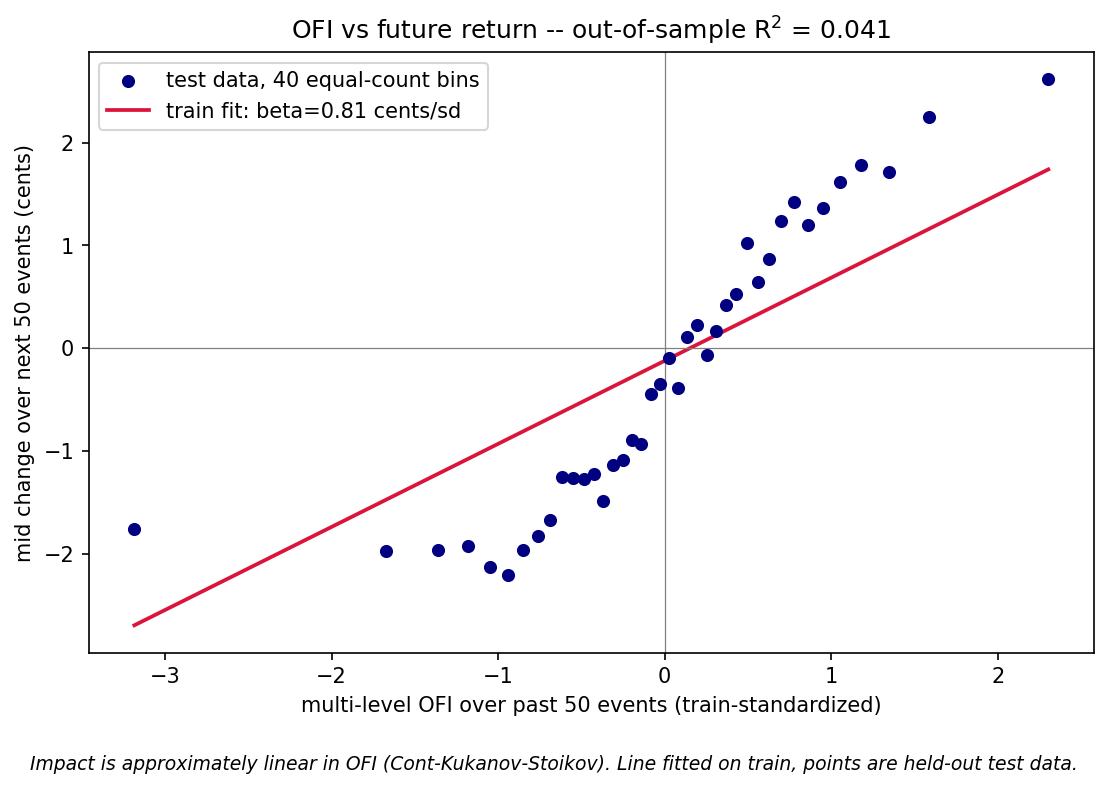

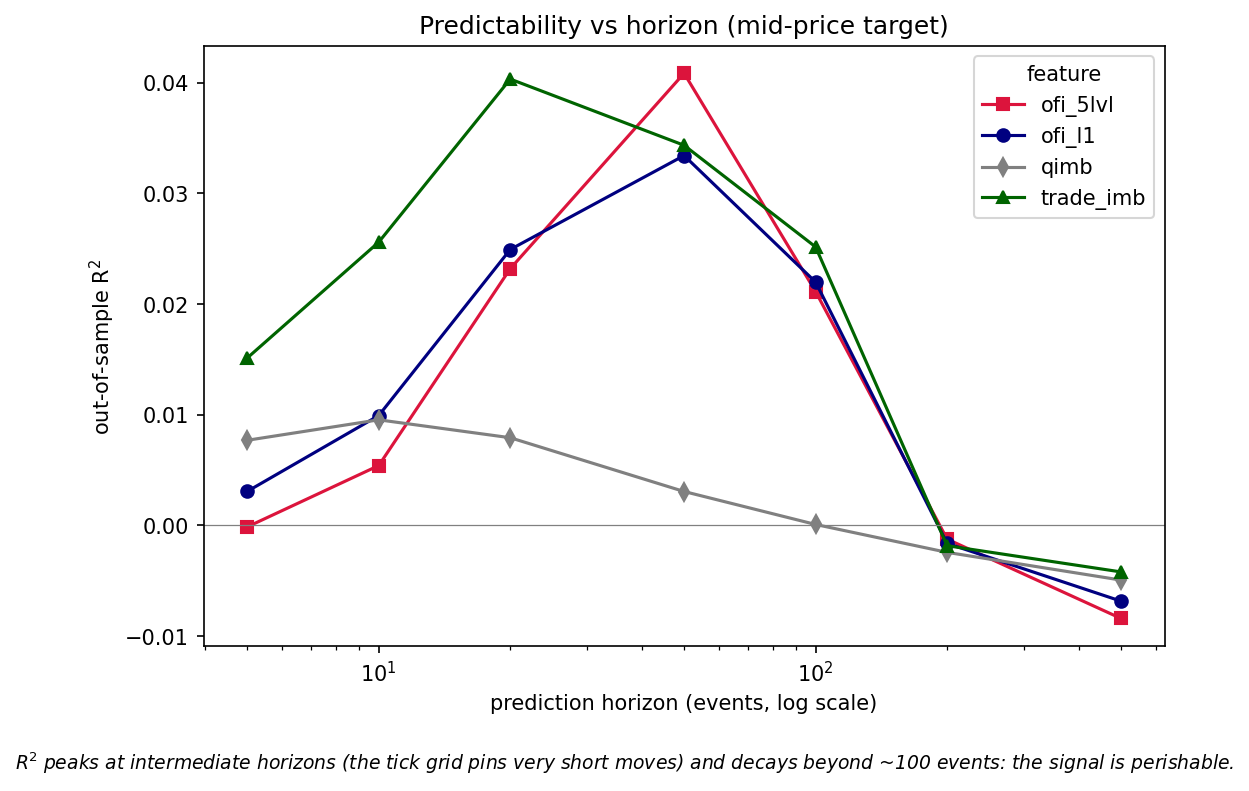

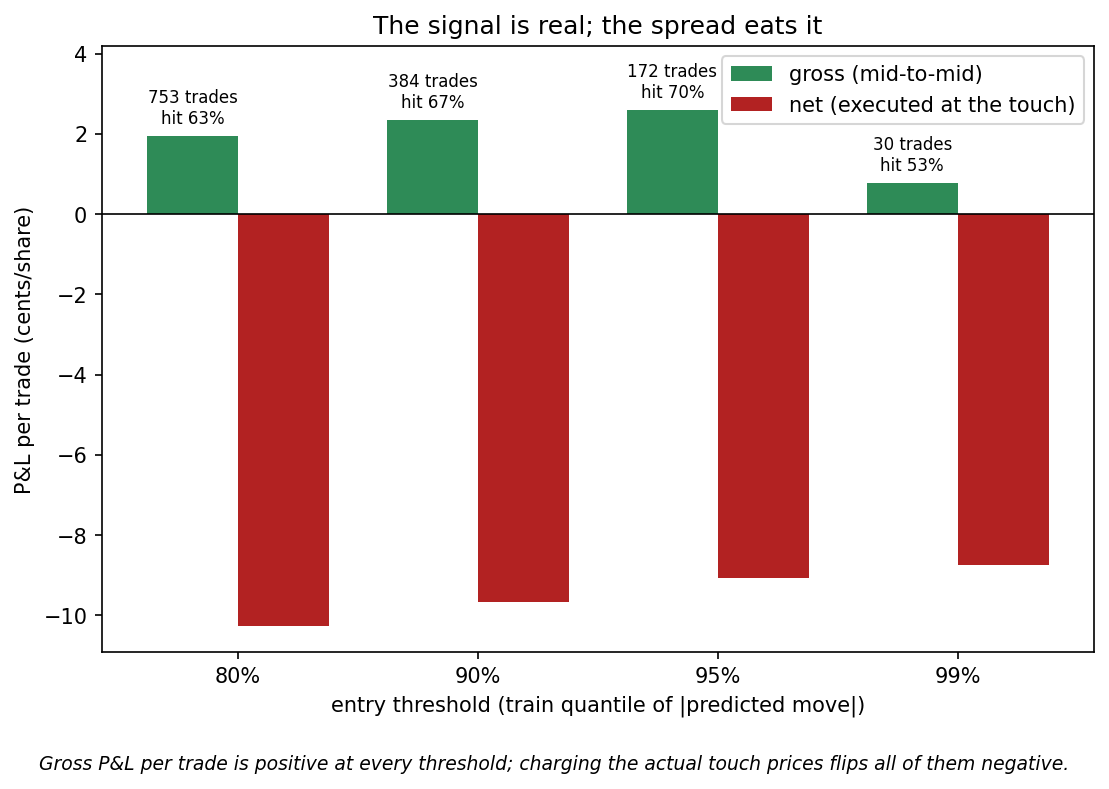

In [6]:
from IPython.display import Image, display
for f in ['fig1_ofi_vs_return.png', 'fig2_r2_decay.png', 'fig3_cost_honesty.png']:
    display(Image(filename=str(pathlib.Path.cwd().parent / 'results' / f)))

## 6. Cost-honest backtest
Gross positive at every threshold, net negative at every threshold: the spread (≈15¢ round trip) is ~5× the captured edge (≈2.3¢).

In [7]:
threshold_sweep(book, feats['ofi_5lvl'], y, H).round(4)

,tau_quantile,tau_dollars,n_trades,hit_rate,gross_per_trade,cost_per_trade,net_per_trade,gross_total,net_total,sharpe_like
0,0.80,0.0087,753,0.6321,0.0195,0.1221,-0.1026,14.660,-77.29,-42.8264
1,0.90,0.0121,384,0.6719,0.0234,0.1199,-0.0965,8.985,-37.07,-27.7253
2,0.95,0.0158,172,0.7035,0.0259,0.1165,-0.0906,4.455,-15.58,-18.9334
3,0.99,0.0264,30,0.5333,0.0078,0.0952,-0.0873,0.235,-2.62,-8.0783


**Takeaway.** OFI predicts the next ~50 events with OOS R² ≈ 4% and the impact is linear (CKS).
The edge is real information about adverse selection, monetizable only by participants who
earn the spread (queue position) rather than pay it. Details and limitations: `README.md`.